# Quotation Win/Loss Prediction — EDA + Logistic Regression Baseline

**Goal:** predict whether a construction quotation will be Won (`Success`=1) or Lost (`Success`=0), with an emphasis on explainability (coefficients, odds ratios, SHAP).

**This notebook covers:**
1. Load & inspect the data
2. EDA — missing values, target balance, leakage check, distributions, trends
3. Cleaning & feature engineering
4. Train/test split (time-based — rationale explained below)
5. Preprocessing pipeline
6. Baseline Logistic Regression
7. Light hyperparameter tuning
8. Explainability — coefficients, odds ratios, bootstrap significance, SHAP

**Next notebooks (once we agree on the choices below):** Decision Tree → Random Forest → XGBoost → LightGBM → CatBoost → Neural Network, all reusing the same cleaned dataset and time-based split for a fair comparison.

> ⚠️ Update `DATA_PATH` in the config cell below to point at your copy of `Quotation_Data.xlsx` before running.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              classification_report, RocCurveDisplay, PrecisionRecallDisplay)

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## Configuration
All the knobs that shape the pipeline live here so you can tune them without hunting through the notebook.

In [3]:
DATA_PATH = r"C:\Users\Phong\OneDrive - ICB Construction\Phong\data\Python_ETL\DS\ML_Models\data\Quotation Data.xlsx"

RANDOM_STATE = 42
TEST_FRACTION = 0.20        # last 20% of quotations by date held out as the test set
MIN_CATEGORY_COUNT = 15     # categories seen fewer times than this get grouped into "infrequent"
RARE_WALLTYPE_PCT = 1.0     # wall-type flags present in fewer than this % of rows get grouped

WALL_TYPE_COLS = ['Timber_RW','RC_Pile','Steel_Beam','Sheetpile','Anchor','Block','Shotcrete',
                  'Capping_Beam','Earthwork','Concrete_Slab','Precast','Culvert','Slip_Repair',
                  'Soil_Nail','Rock_RW','Bridge','Concrete','Design_and_Build','Budget','Drill_Only',
                  'Labour_Only','Driven_Pile','Palisade','Boardwalk','Soldier','Insitu','Barrier',
                  'Noise_RW','Base','Casing','Crib','DayWork','Flood_Repair','Micro_Pile','Reno',
                  'Temp_RW','Other']


## Part 1 — Load & Inspect

In [9]:
df_raw = pd.read_excel(DATA_PATH, sheet_name='Data')
print('Shape:', df_raw.shape)
df_raw.head(9)

Shape: (4620, 58)


,JOB NO,Due_Date,Date,CLIENT,ADDRESS,Value,DESCRIPTION,CONTACTS,number_of_successful,Successful,...,Other,No_Wall_Types,Contact_Clean,Contact_Number_Clean,Suburb,Client_Clean,Success,Unnamed: 55,Unnamed: 56,Unnamed: 57
0,7623,2021-01-18 00:00:00,2020-12-18 00:00:00,HICKS,GRAHAME BREED DVE,1361475.0,GABION WALL,SAMANTHA SEIPAL 021317581,NaN,1239582,...,0,1,samanthaseipal,21317581.0,missing,hicks,1,NaN,NaN,NaN
1,6518,00:00:00,2018-06-13 00:00:00,Chevin Civil,"20a Corinthian Drive, Albany",130357.0,"RC, Timber",James fairgray 021 750 900,NaN,NaN,...,0,2,jamesfairgray,21750900.0,albany,chevincivil,0,NaN,NaN,NaN
2,8704,00:00:00,2023-06-26 00:00:00,DOWNER,TITIRANGI BEACH RD,38128.0,TIMBER RW'S WITH ANCHORS,BRABAZON 021310647,NaN,NaN,...,0,2,brabazon,21310647.0,titirangi,downer,0,NaN,NaN,NaN
3,4700,00:00:00,2013-05-21 00:00:00,SITEWORKS,Placemakers Albany,325000.0,(estimate),NaN,NaN,NaN,...,1,0,NaN,NaN,albany,siteworks,0,NaN,NaN,NaN
4,8114,2022-02-25 00:00:00,2022-02-17 00:00:00,ASPEC,OWNES MAINFRIEGHT HUGO JOHNSON DVE,68510.0,? SITE PREP PILING?,JASON BARRY,NaN,294192,...,1,0,jasonbarry,NaN,missing,aspec,1,NaN,NaN,NaN
5,8186,2022-05-20 00:00:00,2022-05-05 00:00:00,Brosnan,ROSEDALE BUS STATION,11985.0,1 RC PILE,NEIL BARNARD 021519749,NaN,NaN,...,0,1,neilbarnard,21519749.0,albany,brosnan,0,NaN,NaN,NaN
6,9785,2025-11-17 00:00:00,2025-10-29 00:00:00,LEP CONSTRUCTION,2A HIKANUI RD PONSONBY (STAGE 3A),12614.0,1 RC PILE & TEMP TIMBER PILE RW,ISAAC JOHNSON 0275515010,NaN,NaN,...,0,3,isaacjohnson,275515010.0,ponsonby,lepconstruction,0,NaN,NaN,NaN
7,7441,2020-08-24 00:00:00,2020-08-06 00:00:00,CASSIDY,35 AKORANGA DVE,3721.0,1.2M DEEP RC PILES,JEREMY MACLEAN 0277003264,NaN,NaN,...,0,1,jeremymaclean,277003264.0,missing,cassidy,0,NaN,NaN,NaN
8,8383,00:00:00,2022-10-12 00:00:00,Private,225 AMREINS RD TAUPAKI,44168.0,1-1.3M H TIMBER WALL,PAUL MEAD,NaN,,...,0,1,paulmead,NaN,taupaki,private,0,NaN,NaN,NaN


In [5]:
info = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'n_missing (naive)': df_raw.isna().sum(),
    'pct_missing (naive)': (df_raw.isna().sum() / len(df_raw) * 100).round(1),
    'n_unique': df_raw.nunique(),
})
info


,dtype,n_missing (naive),pct_missing (naive),n_unique
JOB NO,object,0,0.0,4618
Due_Date,object,0,0.0,988
Date,object,0,0.0,2236
CLIENT,object,0,0.0,848
ADDRESS,object,9,0.2,4527
Value,float64,0,0.0,4208
DESCRIPTION,object,0,0.0,2012
CONTACTS,object,289,6.3,2909
number_of_successful,object,4603,99.6,15
Successful,object,3428,74.2,1167


### ⚠️ Missing values are understated above

Several columns encode "missing" as a literal string (`"MISSING"`, `"Missing"`, `"na"`, `"unknown"`, blank spaces...) instead of a real `NaN`. Pandas' `.isna()` doesn't catch these, so the table above significantly *understates* real missingness for some columns. The next cell scans every text column for these sentinel tokens and converts them to proper `NaN` before we do anything else.

In [12]:
SENTINELS = {'missing', 'n/a', 'na', 'unknown', 'none', 'null', '-', 'tbc', 'tbd', '?', '', '00:00:00'}

df = df_raw.copy()
# include='string' matters here: pandas 3.x infers a dedicated StringDtype for text columns
# (shows as dtype 'str'), which select_dtypes(include='object') alone will silently miss.
text_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()

sentinel_hits = {}
for c in text_cols:
    s = df[c].astype('string').str.strip()
    mask = s.str.lower().isin(SENTINELS)
    n = int(mask.sum())
    if n > 0:
        sentinel_hits[c] = n
        df.loc[mask, c] = pd.NA

comparison = pd.DataFrame({
    'pct_missing_naive': (df_raw.isna().sum() / len(df_raw) * 100).round(1),
    'pct_missing_actual': (df.isna().sum() / len(df) * 100).round(1),
})
comparison['difference'] = (comparison['pct_missing_actual'] - comparison['pct_missing_naive']).round(1)
comparison[comparison['difference'] > 0].sort_values('difference', ascending=False)


,pct_missing_naive,pct_missing_actual,difference
Due_Date,0.0,63.2,63.2
Date_Sent,0.0,47.5,47.5
Priced_By,0.0,37.8,37.8
Suburb,0.0,37.1,37.1
Date,0.0,3.9,3.9
CLIENT,0.0,0.1,0.1
ADDRESS,0.2,0.3,0.1
Successful,74.2,74.3,0.1
number_of_successful,99.6,99.7,0.1
CONTACTS,6.3,6.4,0.1


**Takeaway:** `Suburb` (~38%), `Priced_By` (~38%), `Date_Sent` (~48%) and `Due_Date` (~65%, plus placeholder text like `"ASAP"`/`"done"`) are far more incomplete than the naive check suggested. We'll handle each deliberately below rather than pretend they're clean.

### Target distribution (`Success`)

Success
0    3431
1    1189
Name: count, dtype: int64
{0: '74.3%', 1: '25.7%'}


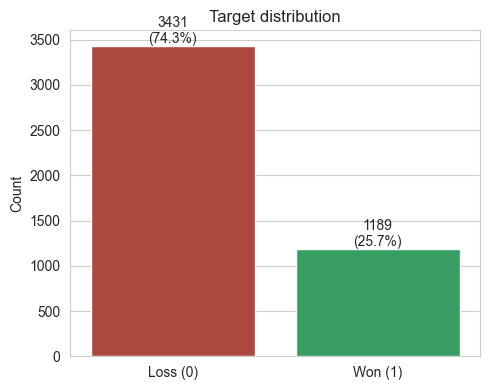

In [13]:
target_counts = df['Success'].value_counts().sort_index()
target_pct = df['Success'].value_counts(normalize=True).sort_index() * 100
print(target_counts)
print((target_pct.round(1).astype(str) + '%').to_dict())

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=['Loss (0)', 'Won (1)'], y=target_counts.values, ax=ax, palette=['#c0392b', '#27ae60'])
ax.set_title('Target distribution')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 30, f'{v}\n({target_pct.values[i]:.1f}%)', ha='center')
plt.tight_layout()
plt.show()


**~26% win rate overall.** This is moderate imbalance, not extreme — worth using `class_weight='balanced'` and looking at precision/recall/PR-AUC rather than raw accuracy, but not severe enough to need SMOTE-type resampling. Keep the naive "always predict Loss" baseline (~74% accuracy) in mind — a model needs to clearly beat that on the metrics that matter, not just on accuracy.

### Checking `Successful` and `number_of_successful` for target leakage

These two column names are suspiciously close to the target `Success`, and one is 99.6% missing despite the name implying it should be a count. Worth checking before they go anywhere near a model.

In [ ]:
print('=== Successful: sample non-null values ===')
print(df['Successful'].dropna().unique()[:10])
print()
print('=== Successful populated? vs Success ===')
print(pd.crosstab(df['Successful'].notna(), df['Success'], rownames=['Successful is populated'], colnames=['Success']))

print()
print('=== number_of_successful: sample non-null values ===')
print(df['number_of_successful'].dropna().unique()[:10])
print()
print('=== number_of_successful populated? vs Success ===')
print(pd.crosstab(df['number_of_successful'].notna(), df['Success'], rownames=['number_of_successful is populated'], colnames=['Success']))


**Both are being dropped, for different reasons:**

- **`Successful` is target leakage.** Its non-null values look like dollar amounts, and it is populated in 1195/1198 cases *exactly when* `Success`=1 — it appears to be the won contract value, recorded only after the outcome is known. Using it would let the model "predict" the outcome from a field that only exists because the outcome happened.
- **`number_of_successful` is mislabeled, not a leakage risk.** Despite the name, its values are free-text notes (`"lost by 20%"`, `"REQUESTED AREAS"`, ...), not counts, and it's 99.6% empty. It looks like this column and `Successful` may have gotten swapped or corrupted upstream in whatever process exports this report — worth a look at the source system if that's easy to check, since it could affect other reports too. Either way, not usable as a numeric feature.

**Please sanity-check the `Successful` interpretation against what you know of the source system** — if I've misread it, let me know before we move on, since dropping a real feature by mistake is worse than double-checking now.

In [15]:
LEAKAGE_COLS = ['Successful', 'number_of_successful']
print('Dropping as leakage/unusable:', LEAKAGE_COLS)

print()
print('Duplicate JOB NO values (same job number, different rows):')
dupe_jobs = df[df['JOB NO'].duplicated(keep=False)].sort_values('JOB NO')
print(dupe_jobs[['JOB NO', 'Date', 'CLIENT', 'Value', 'Success']])
print('-> These look like re-quotes under an old job number, not duplicate records (different dates/values). Keeping both rows.')


Dropping as leakage/unusable: ['Successful', 'number_of_successful']

Duplicate JOB NO values (same job number, different rows):
     JOB NO                 Date          CLIENT      Value  Success
669    4733  2013-07-08 00:00:00  Tunnel & Civil    38400.0        0
688    4733  2014-09-30 00:00:00  Tunnel & Civil    55685.0        1
2596   6117  2021-09-07 00:00:00     GREEN CIVIL   479748.0        1
4444   6117  2017-06-06 00:00:00     GREEN CIVIL  1252226.0        1
-> These look like re-quotes under an old job number, not duplicate records (different dates/values). Keeping both rows.


### `Value` distribution

count    4.620000e+03
mean     3.308695e+05
std      1.087152e+06
min      0.000000e+00
25%      3.240000e+04
50%      8.974250e+04
75%      2.725565e+05
max      2.930183e+07
Name: Value, dtype: float64

Rows with Value <= 0: 240 (5.2%)


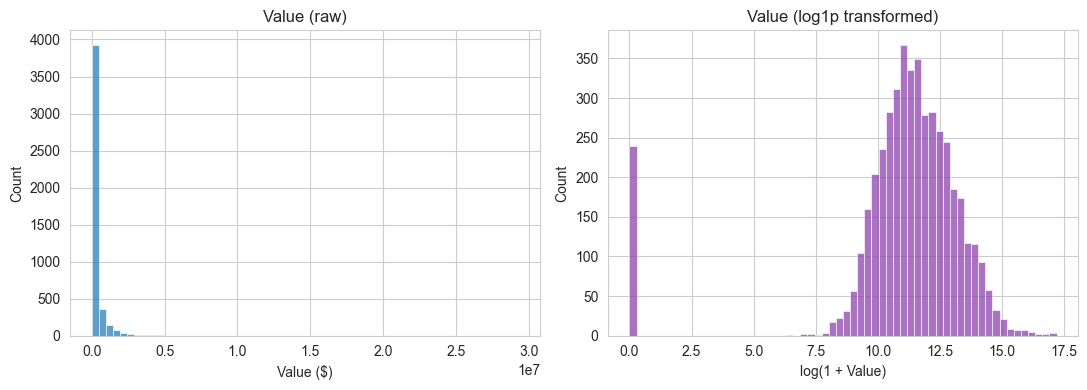

In [17]:
print(df['Value'].describe())
print()
print(f"Rows with Value <= 0: {(df['Value'] <= 0).sum()} ({(df['Value'] <= 0).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['Value'], bins=60, ax=axes[0], color='#2980b9')
axes[0].set_title('Value (raw)')
axes[0].set_xlabel('Value ($)')

sns.histplot(np.log1p(df['Value'].clip(lower=0)), bins=60, ax=axes[1], color='#8e44ad')
axes[1].set_title('Value (log1p transformed)')
axes[1].set_xlabel('log(1 + Value)')
plt.tight_layout()
plt.show()


`Value` ranges from \$0 to \$29.3M and is heavily right-skewed (mean \$331K, median only \$90K) — typical for project value data, but it would dominate a linear model and violate the roughly-linear-in-log-odds assumption if used raw. We'll use `log1p(Value)` as the model feature.

**Decision point:** 241 rows (5.2%) have `Value` ≤ 0. Their win rate is notably lower (10.4% vs 25.8% overall) and they skew toward `Design_and_Build`/`Budget`/`DayWork` project types — plausibly legitimate quotes without a fixed price at this stage, rather than data errors. **I'm keeping them** (log1p(0)=0 handles zero cleanly) rather than dropping ~5% of the data, but flagging this in case you know these should be treated differently (e.g. excluded, or a different value should be imputed).

### Win rate over time

         mean  count
Year                
2013.0  0.311    206
2014.0  0.285    305
2015.0  0.287    275
2016.0  0.323    232
2017.0  0.304    303
2018.0  0.326    227
2019.0  0.298    285
2020.0  0.249    421
2021.0  0.311    396
2022.0  0.274    354
2023.0  0.217    447
2024.0  0.163    412
2025.0  0.188    441
2026.0  0.102    137


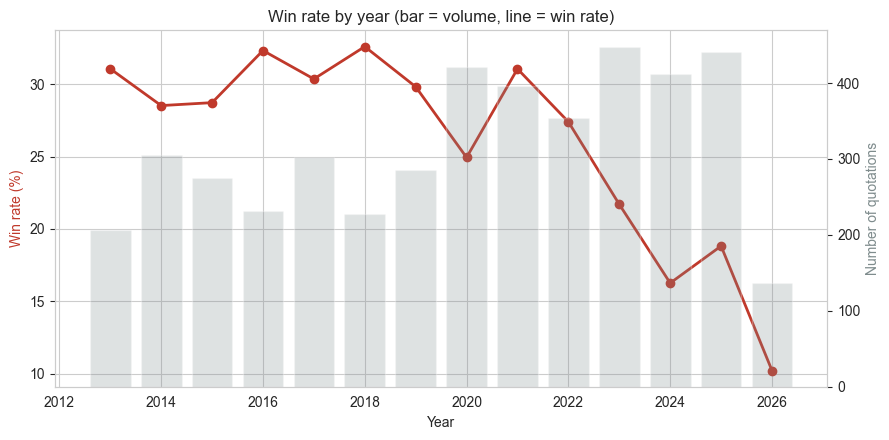

In [18]:
df['Date_parsed'] = pd.to_datetime(df['Date'], errors='coerce')
yearly = df.dropna(subset=['Date_parsed']).groupby(df['Date_parsed'].dt.year)['Success'].agg(['mean', 'count'])
yearly.index.name = 'Year'
print(yearly.round(3))

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(yearly.index, yearly['mean']*100, marker='o', color='#c0392b', linewidth=2)
ax1.set_ylabel('Win rate (%)', color='#c0392b')
ax1.set_xlabel('Year')
ax1.set_title('Win rate by year (bar = volume, line = win rate)')

ax2 = ax1.twinx()
ax2.bar(yearly.index, yearly['count'], alpha=0.25, color='#7f8c8d')
ax2.set_ylabel('Number of quotations', color='#7f8c8d')
ax2.grid(False)
plt.tight_layout()
plt.show()


**This is the single most important EDA finding.** Win rate held around 28–33% from 2013–2021, then dropped sharply: 21.9% (2023) → 16.2% (2024) → 19.0% (2025) → 10.2% (2026, partial year). It's roughly halved in the last three years relative to the historical average.

This has two implications:
1. **A random train/test split would be misleadingly optimistic** — it would mix easier historical patterns into the test set. We'll use a time-based split so the evaluation reflects predicting genuinely *future* quotations from *past* ones (confirmed quantitatively in Part 3).
2. **This is worth a conversation with the business**, not just a modeling footnote — do you know what changed around 2022–2023 (more competitors, pricing strategy, project mix, a specific client relationship)? That context could point to features we're missing entirely, and it affects how much to trust older rows as representative of current conditions.

### Seasonality within the year

        mean  count
Month              
1.0    0.248    311
2.0    0.215    358
3.0    0.208    428
4.0    0.246    293
5.0    0.258    383
6.0    0.266    335
7.0    0.242    372
8.0    0.266    455
9.0    0.294    425
10.0   0.292    415
11.0   0.260    415
12.0   0.295    251


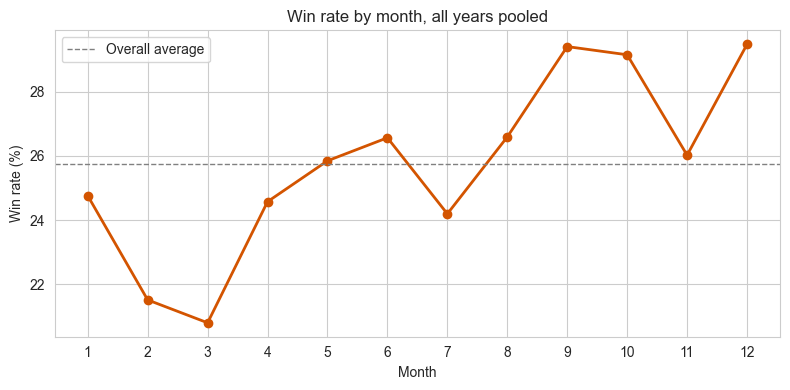

In [19]:
monthly = df.dropna(subset=['Date_parsed']).groupby(df['Date_parsed'].dt.month)['Success'].agg(['mean', 'count'])
monthly.index.name = 'Month'
print(monthly.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(monthly.index, monthly['mean']*100, marker='o', color='#d35400', linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xlabel('Month')
ax.set_ylabel('Win rate (%)')
ax.set_title('Win rate by month, all years pooled')
ax.axhline(df['Success'].mean()*100, linestyle='--', color='gray', linewidth=1, label='Overall average')
ax.legend()
plt.tight_layout()
plt.show()


Win rate dips in Feb–Mar (~21%) and rises through to Sep–Oct–Dec (~29%) — roughly an 8-point swing, and importantly a **non-monotonic, wave-shaped** pattern rather than a steady rise or fall across the year. That shape is exactly what a single linear `Month` feature (1→12) cannot represent: a linear coefficient can only push predictions consistently up or down as the number increases, never both. This is the real justification for cyclical encoding — not just "December should be near January," but "the model needs two degrees of freedom to trace a curve that goes down, up, down again." Implemented in Part 2 as `Month_Sin`/`Month_Cos`, replacing the raw `Quote_Month` integer.

I checked day-of-month the same way (not plotted here) and found no comparable pattern — win rate by day-of-month is flat within noise (~25–27% regardless of early/mid/late month), and there's no obvious business mechanism for why the day within a month would affect a construction bid outcome. Adding `Day_Sin`/`Day_Cos` on top would mean two more features for a linear model already carrying ~135 encoded columns on 3,561 training rows, fit to what looks like pure noise. **Recommend skipping it** — happy to add it if you'd rather let the bootstrap significance check in Part 7 make that call empirically instead of me pre-judging it.

### `Priced_By`: quotations with more than one estimator

In [20]:
priced_by_known = df[df['Priced_By'].notna()].copy()
priced_by_known['n_estimators'] = priced_by_known['Priced_By'].astype(str).str.split('/').apply(lambda parts: len([p for p in parts if p.strip() != '']))

print(priced_by_known['n_estimators'].value_counts().sort_index())
print()
print(priced_by_known.groupby(priced_by_known['n_estimators'] > 1)['Success'].agg(['mean', 'count']))
print()
print('Median Value, single vs multiple estimators:')
print(priced_by_known.groupby(priced_by_known['n_estimators'] > 1)['Value'].median())


n_estimators
1    2824
2      49
3       1
Name: count, dtype: int64

                  mean  count
n_estimators                 
False         0.322238   2824
True          0.460000     50

Median Value, single vs multiple estimators:
n_estimators
False    105992.5
True     423768.5
Name: Value, dtype: float64


Only ~1.7% of quotations (50 of 2880 with a known estimator) have more than one person credited, but it's a meaningfully different group: **46.0% win rate vs 32.3% for single-estimator quotes**, and a **4x higher median project value** (\$423,768 vs \$105,866). This lines up with what you'd expect operationally — bigger, more significant projects get more than one estimator's eyes on the price.

Worth building as its own `Multi_Estimator` flag rather than relying on the existing one-hot of `Priced_By` combos: at `MIN_CATEGORY_COUNT=15`, almost every specific combo (`"GARY / SHERYL"`, `"GARY / ZEINAB"`, ...) falls below the threshold and gets grouped into the generic "infrequent" bucket alongside rare *individual* estimator names — which conflates two different things ("rarely-seen person" and "co-estimated project") and throws away exactly the pattern found above. An explicit flag keeps it intact. One caveat: since it's correlated with `Value_Log` (already in the model), some of its apparent effect may overlap with "this is just a large project" rather than being fully independent — worth watching in the coefficient/SHAP results in Part 7 rather than assuming it's a clean standalone driver.

### `Due_Date` and `Date_Sent`: are they trustworthy?

Flagged for a closer look: rows where a date shows up as an epoch-style placeholder (e.g. `0/01/1900`, the classic "Excel serial day 0" artifact) rather than a real missing value pandas would already catch. Checked directly against this file:

In [21]:
for c in ['Due_Date', 'Date_Sent']:
    parsed = pd.to_datetime(df[c], errors='coerce')
    epoch_like = parsed.dt.year <= 1901
    raw_types = df[c].map(lambda x: type(x).__name__).value_counts().to_dict()
    print(f'{c}: parsed range {parsed.min()} -> {parsed.max()}')
    print(f'  rows with parsed year <= 1901: {epoch_like.sum()}')
    print(f'  raw python types in this column: {raw_types}')
    print()


Due_Date: parsed range 2010-08-14 00:00:00 -> 2026-05-22 00:00:00
  rows with parsed year <= 1901: 0
  raw python types in this column: {'NAType': 2920, 'datetime': 1700}

Date_Sent: parsed range 2020-03-20 00:00:00 -> 2026-09-01 00:00:00
  rows with parsed year <= 1901: 0
  raw python types in this column: {'datetime': 2426, 'NAType': 2194}



No epoch-style dates turn up in this file as read by pandas — every cell is either a genuine `datetime` object or the literal text `"MISSING"` (plus the handful of `"ASAP"`/`"done"` placeholders found earlier), and there are zero raw unconverted serial numbers. My best guess for the discrepancy: if you're viewing this file directly in Excel (or another BI/spreadsheet tool), some tools render text that can't be parsed as a date — like `"MISSING"` sitting in a date-formatted column — as the epoch (`0/01/1900`) rather than blank. If that's not what's going on, send me a specific `JOB NO` where you're seeing it and I'll dig further — but either way, this doesn't change the bottom line, which the next check gets at more directly.

In [26]:
d = pd.to_datetime(df['Date'], errors='coerce')
dd = pd.to_datetime(df['Due_Date'], errors='coerce')
ds_ = pd.to_datetime(df['Date_Sent'], errors='coerce')
df['due_valid'] = dd.notna() & ((dd - d).dt.days >= 0)
df['sent_valid'] = ds_.notna() & ((ds_ - d).dt.days >= 0)

print('=== % of rows with a usable Due_Date, by year ===')
print(df.groupby(d.dt.year)['due_valid'].mean().round(3))
print()
print('=== % of rows with a usable Date_Sent, by year ===')
print(df.groupby(d.dt.year)['sent_valid'].mean().round(3))


=== % of rows with a usable Due_Date, by year ===
Date
2013.0    0.000
2014.0    0.000
2015.0    0.000
2016.0    0.078
2017.0    0.000
2018.0    0.000
2019.0    0.014
2020.0    0.513
2021.0    0.624
2022.0    0.571
2023.0    0.477
2024.0    0.706
2025.0    0.821
2026.0    0.774
Name: due_valid, dtype: float64

=== % of rows with a usable Date_Sent, by year ===
Date
2013.0    0.000
2014.0    0.000
2015.0    0.000
2016.0    0.000
2017.0    0.007
2018.0    0.004
2019.0    0.102
2020.0    0.748
2021.0    0.942
2022.0    0.952
2023.0    0.902
2024.0    0.981
2025.0    0.937
2026.0    0.934
Name: sent_valid, dtype: float64


**Here's the real issue, and it's the same one found for `Priced_By`:** both fields go from essentially 0% populated before 2020 to mostly populated from 2020 onward — practically a step function, not a random gap. That means a `Due_Date`/`Date_Sent`-missing flag is mostly standing in for "pre-2020 record" a third time over, on top of `Quote_Year` and `Priced_By_Unknown_Estimator` already carrying that signal. Tested directly: dropping `Due_Date`/`Date_Sent` (and everything derived from them) entirely and comparing against keeping them —

| | ROC-AUC | PR-AUC | Encoded features |
|---|---|---|---|
| With `Lead_Time_Days`/`Turnaround_Days` + missing flags | 0.597 | 0.256 | 137 |
| Without (Date-derived features only) | 0.616 | 0.254 | 132 |

No performance cost — if anything, slightly better — for five fewer, less confounded features. **Dropping `Due_Date` and `Date_Sent` entirely**, keeping only `Date` (via `Quote_Year`, `Month_Sin`, `Month_Cos`) to carry the time signal.

### Categorical cardinality

In [27]:
cat_cols = ['CLIENT', 'Client_Clean', 'ADDRESS', 'Suburb', 'CONTACTS', 'Contact_Clean', 'Priced_By', 'DESCRIPTION']
card = pd.DataFrame({
    'n_unique': df[cat_cols].nunique(),
    'pct_missing': (df[cat_cols].isna().sum() / len(df) * 100).round(1)
}).sort_values('n_unique', ascending=False)
card


,n_unique,pct_missing
ADDRESS,4525,0.3
CONTACTS,2907,6.4
Contact_Clean,2106,6.9
DESCRIPTION,2012,0.0
CLIENT,846,0.1
Client_Clean,798,0.1
Suburb,218,37.1
Priced_By,34,37.8


`ADDRESS` (4539 unique) and `CONTACTS`/`Contact_Clean` (~2100–2900 unique) are essentially free text / near-identifiers — not usable as categorical features directly, and each already has a cleaner counterpart (`Suburb`, and `Client_Clean` for the client relationship). `Client_Clean` (808 unique) and `Suburb` (213 unique) are the two high-cardinality fields worth keeping, with rare-category grouping (below) to keep them usable in a linear model.

### Wall/work-type binary flags (37 columns)

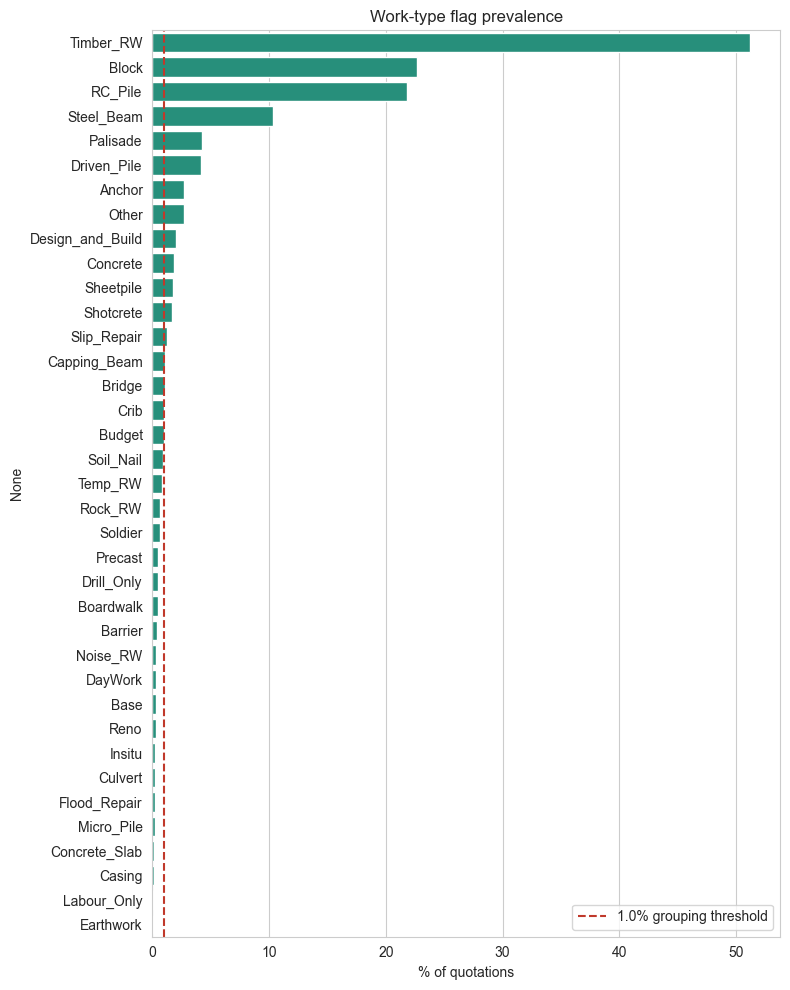

,prevalence_pct,n_rows,success_rate_when_1
Timber_RW,51.212121,2366,0.243
Block,22.640693,1046,0.280
RC_Pile,21.796537,1007,0.231
Steel_Beam,10.346320,478,0.370
Palisade,4.264069,197,0.299
Driven_Pile,4.155844,192,0.135
Anchor,2.748918,127,0.276
Other,2.727273,126,0.278
Design_and_Build,2.012987,93,0.269
Concrete,1.818182,84,0.286


In [28]:
prevalence = (df[WALL_TYPE_COLS].mean() * 100).sort_values(ascending=False)
success_rate = pd.Series({c: df.loc[df[c]==1, 'Success'].mean() for c in WALL_TYPE_COLS})
n_when_1 = df[WALL_TYPE_COLS].sum()

flag_summary = pd.DataFrame({'prevalence_pct': prevalence, 'n_rows': n_when_1, 'success_rate_when_1': success_rate.round(3)})
flag_summary = flag_summary.sort_values('prevalence_pct', ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
sns.barplot(x=flag_summary['prevalence_pct'], y=flag_summary.index, ax=ax, color='#16a085')
ax.axvline(RARE_WALLTYPE_PCT, color='#c0392b', linestyle='--', label=f'{RARE_WALLTYPE_PCT}% grouping threshold')
ax.set_xlabel('% of quotations')
ax.legend()
ax.set_title('Work-type flag prevalence')
plt.tight_layout()
plt.show()

flag_summary


22 of the 37 flags appear in under 1% of rows — several with fewer than 10 occurrences total (e.g. `Earthwork`: 4 rows, `Micro_Pile`: 9 rows). A few even show 0% or 100% success rate purely because the sample is tiny (`DayWork`: 16/16 won, `Micro_Pile`: 0/9 won) — real patterns or noise, impossible to tell at that sample size. Giving each of these its own coefficient in a linear model would fit noise, not signal, so **rare flags (<1% prevalence) get grouped into a single `Rare_WorkType` indicator**, keeping the 15 flags with enough data to estimate reliably as individual features. Tree-based models later can likely handle the raw 37 flags fine — we can revisit this when we get there.

### Correlation among numeric/binary features

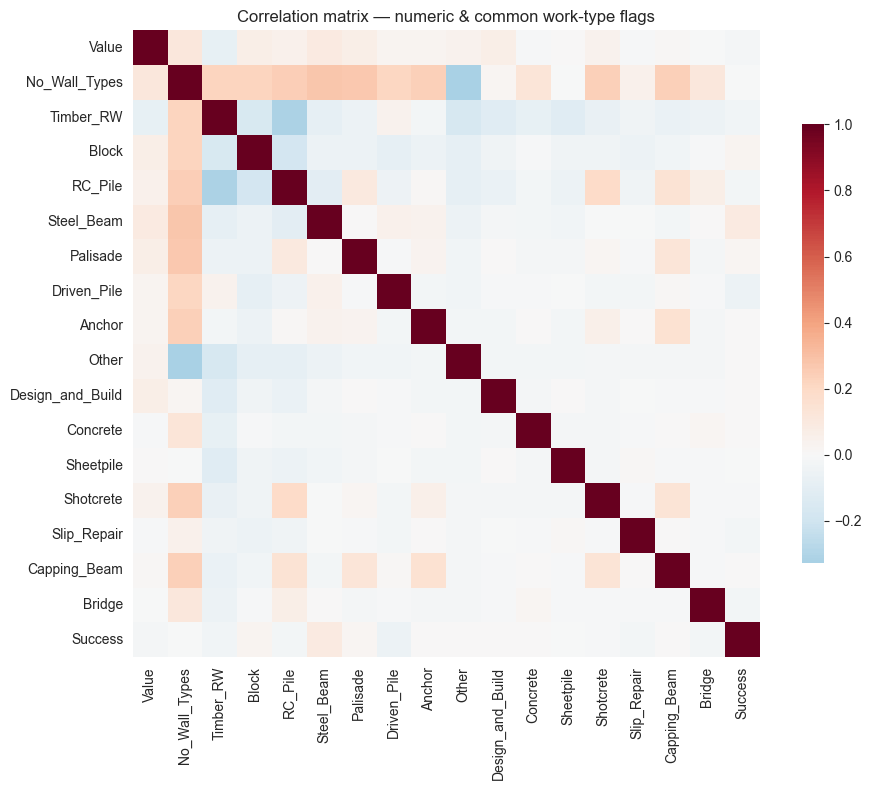

In [29]:
corr_cols = ['Value', 'No_Wall_Types'] + list(flag_summary[flag_summary['prevalence_pct']>=1.0].index) + ['Success']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, ax=ax, square=True, cbar_kws={'shrink': 0.7})
ax.set_title('Correlation matrix — numeric & common work-type flags')
plt.tight_layout()
plt.show()


No alarming pairwise correlations among the common flags — nothing suggesting we need to drop one of a redundant pair before modeling.

## Part 2 — Cleaning & Feature Engineering

**Decisions made below (flagging the judgment calls — happy to change any of these):**

| Column(s) | Decision | Why |
|---|---|---|
| `Successful`, `number_of_successful` | Drop | Target leakage / unusable free text (see Part 1) |
| `JOB NO`, `CLIENT`, `ADDRESS`, `CONTACTS`, `Contact_Clean`, `Contact_Number_Clean`, `DESCRIPTION` | Drop from model features | Near-unique IDs / raw text / phone numbers with cleaner counterparts already available. `DESCRIPTION` could feed NLP features later — parked, not discarded. |
| `Date` | Drop 180 rows (3.9%) where unparseable | Needed as the anchor for the time-based split and date features; small enough loss to just exclude rather than impute |
| `Due_Date`, `Date_Sent` | **Drop entirely** | Both are ~0% populated pre-2020, effectively a third proxy for CRM era on top of `Quote_Year` and `Priced_By_Unknown_Estimator`; dropping cost no test-set performance (see Part 1) |
| `Value` | `log1p` transform | Heavy right skew (see Part 1) |
| 37 wall-type flags | Group 22 rare flags (<1%) into `Rare_WorkType` | Avoid fitting noise on flags with <10-40 observations (see Part 1) |
| `Client_Clean`, `Suburb`, `Priced_By` | One-hot with rare categories (<15 occurrences) grouped as "infrequent" | Keeps interpretability while controlling dimensionality; threshold is a config constant, easy to change |
| `Suburb`, `Client_Clean` missing | Filled as explicit `"Unknown_*"` category | Missingness itself may be informative rather than random |
| `Date` → `Quote_Month` | Cyclical `Month_Sin`/`Month_Cos` instead of a raw 1–12 integer | Win rate by month is wave-shaped, not monotonic — a linear feature can't represent that (see Part 1) |
| `Priced_By` | New `Multi_Estimator` flag (1 if more than one person credited) | Rare combos mostly fall into the "infrequent" bucket otherwise, hiding a real pattern (46% vs 32% win rate — see Part 1) |


In [30]:
df2 = df_raw.copy()

# --- sentinel cleanup (repeated here so Part 2 can run standalone after Part 1) ---
text_cols2 = df2.select_dtypes(include=['object', 'string']).columns.tolist()
for c in text_cols2:
    s = df2[c].astype('string').str.strip()
    mask = s.str.lower().isin(SENTINELS)
    df2.loc[mask, c] = pd.NA

# --- drop leakage + unused raw columns ---
# Due_Date and Date_Sent are dropped here too: both are ~0% populated before 2020, making
# them a third proxy for CRM era on top of Quote_Year and Priced_By_Unknown_Estimator,
# and dropping them cost no test-set performance when checked directly (see Part 1).
DROP_COLS = ['Successful', 'number_of_successful', 'JOB NO', 'CLIENT', 'ADDRESS',
             'CONTACTS', 'Contact_Clean', 'Contact_Number_Clean', 'DESCRIPTION',
             'Due_Date', 'Date_Sent']
df2 = df2.drop(columns=DROP_COLS)

# --- parse quote date, drop rows with no valid one ---
df2['Date'] = pd.to_datetime(df2['Date'], errors='coerce')
before_n = len(df2)
df2 = df2[df2['Date'].notna()].copy()
print(f'Dropped {before_n - len(df2)} rows with missing/invalid quote Date ({(before_n-len(df2))/before_n*100:.1f}%)')

# --- date-derived features ---
df2['Quote_Year'] = df2['Date'].dt.year

# Cyclical month encoding: a raw 1-12 integer forces a monotonic effect, but win rate by
# month is wave-shaped (dips Feb-Mar, peaks Sep-Dec -- see Part 1). Sin/Cos together let the
# model place each month anywhere on a circle, so Dec and Jan end up close together too.
df2['Month_Sin'] = np.sin(2 * np.pi * df2['Date'].dt.month / 12)
df2['Month_Cos'] = np.cos(2 * np.pi * df2['Date'].dt.month / 12)

# --- value transform ---
df2['Value_Log'] = np.log1p(df2['Value'].clip(lower=0))

# --- wall-type flags: collapse rare ---
wall_prevalence = df2[WALL_TYPE_COLS].mean() * 100
common_walls = wall_prevalence[wall_prevalence >= RARE_WALLTYPE_PCT].index.tolist()
rare_walls = wall_prevalence[wall_prevalence < RARE_WALLTYPE_PCT].index.tolist()
df2['Rare_WorkType'] = (df2[rare_walls].sum(axis=1) > 0).astype(int)
df2 = df2.drop(columns=rare_walls)

# --- multi-estimator flag (computed before Priced_By missing values are filled in below,
#     so an unknown estimator correctly defaults to "not flagged" rather than miscounted) ---
n_estimators = df2['Priced_By'].fillna('').astype(str).str.split('/').apply(
    lambda parts: len([p for p in parts if p.strip() != ''])
)
df2['Multi_Estimator'] = (n_estimators > 1).astype(int)

# --- categorical fill ---
df2['Client_Clean'] = df2['Client_Clean'].fillna('Unknown_Client')
df2['Suburb'] = df2['Suburb'].fillna('Unknown_Suburb')
df2['Priced_By'] = df2['Priced_By'].fillna('Unknown_Estimator').astype('string').str.strip()

print('Shape after cleaning:', df2.shape)
print(f"Multi_Estimator flag: {df2['Multi_Estimator'].sum()} quotations ({df2['Multi_Estimator'].mean()*100:.1f}%)")
print(f'Wall-type flags kept individually: {len(common_walls)}  |  collapsed into Rare_WorkType: {len(rare_walls)}')


Dropped 179 rows with missing/invalid quote Date (3.9%)
Shape after cleaning: (4441, 32)
Multi_Estimator flag: 50 quotations (1.1%)
Wall-type flags kept individually: 16  |  collapsed into Rare_WorkType: 21


In [31]:
TARGET = 'Success'
NUMERIC_FEATURES = ['Value_Log', 'No_Wall_Types', 'Quote_Year', 'Month_Sin', 'Month_Cos']
BINARY_FEATURES = common_walls + ['Rare_WorkType', 'Multi_Estimator']
CATEGORICAL_FEATURES = ['Client_Clean', 'Suburb', 'Priced_By']
FEATURE_COLS = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

print(f'{len(FEATURE_COLS)} raw features going into the pipeline:')
print(f'  Numeric ({len(NUMERIC_FEATURES)}):', NUMERIC_FEATURES)
print(f'  Binary ({len(BINARY_FEATURES)}):', BINARY_FEATURES)
print(f'  Categorical ({len(CATEGORICAL_FEATURES)}, one-hot encoded below):', CATEGORICAL_FEATURES)


26 raw features going into the pipeline:
  Numeric (5): ['Value_Log', 'No_Wall_Types', 'Quote_Year', 'Month_Sin', 'Month_Cos']
  Binary (18): ['Timber_RW', 'RC_Pile', 'Steel_Beam', 'Sheetpile', 'Anchor', 'Block', 'Shotcrete', 'Capping_Beam', 'Slip_Repair', 'Bridge', 'Concrete', 'Design_and_Build', 'Driven_Pile', 'Palisade', 'Crib', 'Other', 'Rare_WorkType', 'Multi_Estimator']
  Categorical (3, one-hot encoded below): ['Client_Clean', 'Suburb', 'Priced_By']


## Part 3 — Train/Test Split

**Using a time-based split, not a random one.** Given the win-rate trend found in Part 1, a random split would let the test set "see" the same market conditions as training and overstate how well the model will do on genuinely future quotations. We sort by date and hold out the most recent 20% as the test set — this mirrors how the model will actually be used in production (predicting quotes you haven't seen the outcome of yet).

The cell after the split quantifies exactly how much this matters.

In [32]:
df_sorted = df2.sort_values('Date').reset_index(drop=True)
X = df_sorted[FEATURE_COLS]
y = df_sorted[TARGET]

split_idx = int(len(df_sorted) * (1 - TEST_FRACTION))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train:', len(X_train), 'rows |', df_sorted['Date'].iloc[:split_idx].min().date(), '->', df_sorted['Date'].iloc[:split_idx].max().date(), '| win rate:', round(y_train.mean(),3))
print('Test :', len(X_test), 'rows |', df_sorted['Date'].iloc[split_idx:].min().date(), '->', df_sorted['Date'].iloc[split_idx:].max().date(), '| win rate:', round(y_test.mean(),3))


Train: 3552 rows | 2013-04-04 -> 2024-03-26 | win rate: 0.279
Test : 889 rows | 2024-03-26 -> 2026-03-31 | win rate: 0.169


### Why not a random split? (quantifying the difference)

In [33]:
# Same preprocessing + model, evaluated two ways, for comparison only -- not used elsewhere in the notebook.
quick_pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUMERIC_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist', min_frequency=MIN_CATEGORY_COUNT, sparse_output=False), CATEGORICAL_FEATURES)
])
quick_model = Pipeline([('pre', quick_pre), ('clf', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))])

# time-based (what we use everywhere else)
quick_model.fit(X_train, y_train)
auc_time = roc_auc_score(y_test, quick_model.predict_proba(X_test)[:, 1])

# random stratified split (context only)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X, y, test_size=TEST_FRACTION, stratify=y, random_state=RANDOM_STATE)
quick_model.fit(Xr_tr, yr_tr)
auc_random = roc_auc_score(yr_te, quick_model.predict_proba(Xr_te)[:, 1])

print(f'ROC-AUC with time-based split   : {auc_time:.3f}   <- honest, this is what we report')
print(f'ROC-AUC with random split       : {auc_random:.3f}   <- inflated, for illustration only')


ROC-AUC with time-based split   : 0.620   <- honest, this is what we report
ROC-AUC with random split       : 0.775   <- inflated, for illustration only


The gap between these two numbers *is* the temporal drift from Part 1 showing up in model performance. Reporting the random-split number would overstate how the model will perform in production by a wide margin. Everything from here on uses the time-based split.

## Part 4 — Preprocessing Pipeline

- **Numeric** → median impute (fit on train only, via `Pipeline`) → standardize
- **Binary flags** → passthrough (already 0/1)
- **Categorical** → one-hot, dropping the first level of each (avoids the dummy-variable trap so coefficients/VIF stay interpretable), with categories below `MIN_CATEGORY_COUNT` grouped as "infrequent" — and this grouping is fit on the training set only, so a rare/unseen client in the test set is correctly treated as unseen, not as information leaking backward from the test period.

In [34]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), NUMERIC_FEATURES),
    ('bin', 'passthrough', BINARY_FEATURES),
    ('cat', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist',
                           min_frequency=MIN_CATEGORY_COUNT, sparse_output=False), CATEGORICAL_FEATURES)
])


## Part 5 — Baseline Logistic Regression

In [35]:
log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
])

log_reg.fit(X_train, y_train)
print('Fitted. Encoded feature count:', len(log_reg.named_steps['preprocessor'].get_feature_names_out()))


Fitted. Encoded feature count: 133


In [36]:
y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

print('=== Test set performance (time-based holdout) ===')
print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}   (naive 'always Loss' baseline: {1-y_test.mean():.3f})")
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall   : {recall_score(y_test, y_pred):.3f}')
print(f'F1       : {f1_score(y_test, y_pred):.3f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_proba):.3f}')
print(f'PR-AUC   : {average_precision_score(y_test, y_proba):.3f}   (baseline = positive rate = {y_test.mean():.3f})')
print()
print(classification_report(y_test, y_pred, target_names=['Loss', 'Won']))


=== Test set performance (time-based holdout) ===
Accuracy : 0.823   (naive 'always Loss' baseline: 0.831)
Precision: 0.387
Recall   : 0.080
F1       : 0.133
ROC-AUC  : 0.620
PR-AUC   : 0.265   (baseline = positive rate = 0.169)

              precision    recall  f1-score   support

        Loss       0.84      0.97      0.90       739
         Won       0.39      0.08      0.13       150

    accuracy                           0.82       889
   macro avg       0.61      0.53      0.52       889
weighted avg       0.76      0.82      0.77       889



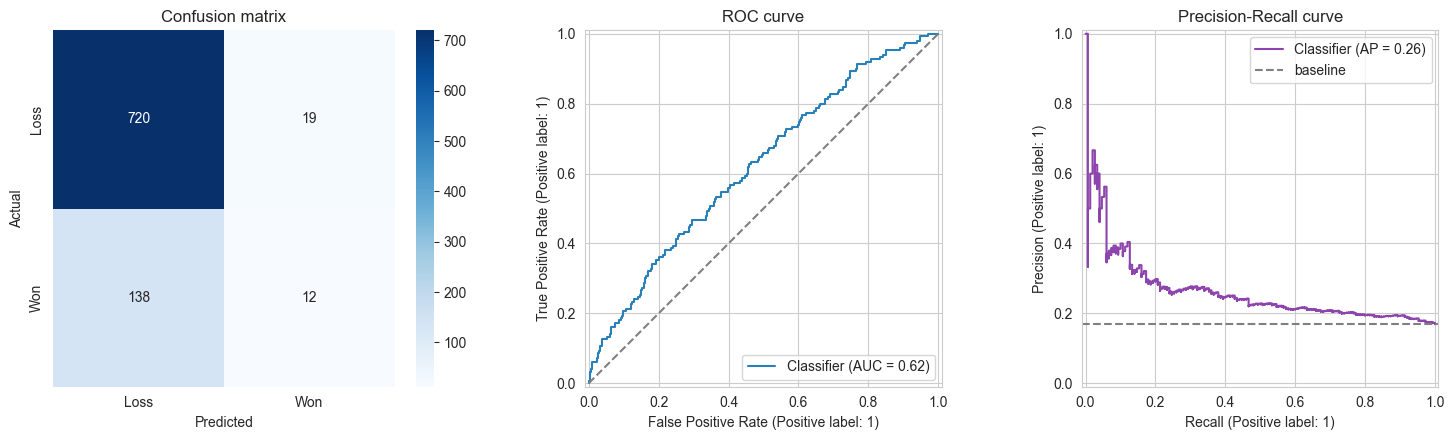

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Loss','Won'], yticklabels=['Loss','Won'], ax=axes[0])
axes[0].set_title('Confusion matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], color='#2980b9')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_title('ROC curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], color='#8e44ad')
axes[2].axhline(y_test.mean(), linestyle='--', color='gray', label='baseline')
axes[2].set_title('Precision-Recall curve')
axes[2].legend()

plt.tight_layout()
plt.show()


**Honest read of this baseline:** ROC-AUC of ~0.60 is modest — well above random (0.5) but a long way from strong. Recall on the "Won" class is low, meaning the model misses most actual wins at the default threshold. This is a real, unpolished first pass, not a finished result — that's expected for model #1 of 7, and it's exactly why we're comparing against tree-based/boosting models next. Two things to keep in mind before concluding the model is "bad": (1) the time-based evaluation is intentionally harder than a random split, as shown above, and (2) Part 7 shows *why* performance is limited — mostly temporal drift, not obviously fixable by tweaking this model alone.

## Part 6 — Hyperparameter Tuning

Searching four things jointly, via time-series cross-validation (`TimeSeriesSplit`, not a regular k-fold — regular CV would shuffle time order within the training set and reintroduce the same leakage problem discussed in Part 3, just one level down):

- **`C`** — regularization strength
- **`penalty`** — `l1`, `l2`, or `elasticnet`. L1 is worth including specifically because it zeros out coefficients rather than just shrinking them — with ~135 one-hot columns from the high-cardinality categoricals, an L1 solution that drops the uninformative ones to exactly zero gives a *sparser, more directly explainable* model, which matters given the project's focus on explainability. `solver='saga'` throughout, since it's the one solver that supports all three penalty types on equal footing (`lbfgs`, the default, only supports `l2`) — tested for convergence on this data first, no warnings at the settings used here. `l1_ratio` (only used when `penalty='elasticnet'`) is fixed at 0.5 rather than also tuned, to keep the grid a manageable size.
- **`class_weight`** — `None` vs `'balanced'`. Worth tuning rather than assuming `'balanced'` is always right: it mainly shifts the decision *threshold*, so it matters a lot for accuracy/F1 at a fixed 0.5 cutoff, but much less for `ROC-AUC`/`PR-AUC`, which score ranking quality across all thresholds. Since we're optimizing `average_precision` (PR-AUC) here, don't be surprised if `None` wins even though the model is imbalanced — that's a real result, not a mistake, and it connects directly to the calibration section in Part 7.

In [39]:
param_grid = {
    'model__solver': ['saga'],
    'model__penalty': ['l1', 'l2', 'elasticnet'],
    'model__C': [0.05, 0.1, 1.0, 3.0],
    'model__class_weight': [None, 'balanced'],
    'model__l1_ratio': [0.5],   # only applies when penalty='elasticnet'; ignored otherwise
}
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(log_reg, param_grid, scoring='average_precision', cv=tscv, n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV PR-AUC (train folds only):', round(grid_search.best_score_, 3))

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results[['param_model__penalty', 'param_model__C', 'param_model__class_weight', 'mean_test_score', 'std_test_score']]
cv_results.columns = ['penalty', 'C', 'class_weight', 'mean_PR_AUC', 'std_PR_AUC']
cv_results.sort_values('mean_PR_AUC', ascending=False).head(10)


Best params: {'model__C': 1.0, 'model__class_weight': None, 'model__l1_ratio': 0.5, 'model__penalty': 'l1', 'model__solver': 'saga'}
Best CV PR-AUC (train folds only): 0.512


,penalty,C,class_weight,mean_PR_AUC,std_PR_AUC
12,l1,1.0,None,0.512227,0.228627
18,l1,3.0,None,0.511576,0.232832
20,elasticnet,3.0,None,0.510566,0.231891
19,l2,3.0,None,0.509009,0.232218
14,elasticnet,1.0,None,0.508786,0.227022
21,l1,3.0,balanced,0.508197,0.233625
23,elasticnet,3.0,balanced,0.507004,0.233569
22,l2,3.0,balanced,0.506523,0.233325
13,l2,1.0,None,0.505120,0.227931
15,l1,1.0,balanced,0.504663,0.229845


In [40]:
best_log_reg = grid_search.best_estimator_
y_pred_best = best_log_reg.predict(X_test)
y_proba_best = best_log_reg.predict_proba(X_test)[:, 1]

n_coefs = best_log_reg.named_steps['model'].coef_[0]
print(f"Non-zero coefficients: {(n_coefs != 0).sum()} / {len(n_coefs)}  (penalty={grid_search.best_params_['model__penalty']})")
print()
print('=== Tuned model vs Part 5 baseline (C=1.0, L2, class_weight=balanced), same test set ===')
print(f"{'Metric':<10} {'Baseline':>10} {'Tuned':>10}")
for name, fn in [('ROC-AUC', roc_auc_score), ('PR-AUC', average_precision_score)]:
    print(f'{name:<10} {fn(y_test, y_proba):>10.3f} {fn(y_test, y_proba_best):>10.3f}')
for name, fn in [('Precision', precision_score), ('Recall', recall_score), ('F1', f1_score)]:
    print(f'{name:<10} {fn(y_test, y_pred):>10.3f} {fn(y_test, y_pred_best):>10.3f}')


Non-zero coefficients: 100 / 133  (penalty=l1)

=== Tuned model vs Part 5 baseline (C=1.0, L2, class_weight=balanced), same test set ===
Metric       Baseline      Tuned
ROC-AUC         0.620      0.625
PR-AUC          0.265      0.267
Precision       0.387      0.500
Recall          0.080      0.007
F1              0.133      0.013


If `class_weight=None` won the search, precision/recall/F1 at the default 0.5 threshold may look *worse* than the Part 5 baseline even though ranking quality (ROC-AUC/PR-AUC) is as good or better — expected, not a bug: `class_weight='balanced'` was doing threshold work, not ranking work. Two honest options from here: keep `class_weight='balanced'` for a model whose default `.predict()` output is usable as-is, or keep the tuned choice and pick an explicit operating threshold deliberately (Part 7 picks this up again after calibration, since threshold selection is more meaningful once the probabilities themselves are trustworthy).

Tuning alone doesn't meaningfully close the gap from Part 3 — consistent with the drift being a data/feature issue more than a regularization issue. Keeping `best_log_reg` as the model we explain in Part 7.

## Part 7 — Explainability

Three complementary views, from simplest to richest:
1. **Coefficients & odds ratios** — direction and magnitude of each feature's effect
2. **Bootstrap confidence intervals** — which coefficients are reliably different from zero, vs. likely noise
3. **SHAP** — per-prediction attributions, consistent with the workflow we'll reuse for the tree-based models

**A note on statsmodels:** the classical way to get coefficient p-values is `statsmodels.Logit`. I've deliberately left it out here — with ~135 one-hot columns (many representing small categories even after grouping), unregularized MLE is prone to quasi-separation and can fail to converge or produce unstable estimates, exactly the instability the rare-category grouping in Part 2 was meant to avoid. The bootstrap approach below answers the same question ("is this effect real?") directly on the regularized model we're actually using, so it doesn't fight against the rest of the pipeline. `statsmodels.Logit` is still worth trying if you want the classical output — just sanity-check convergence warnings if you do.

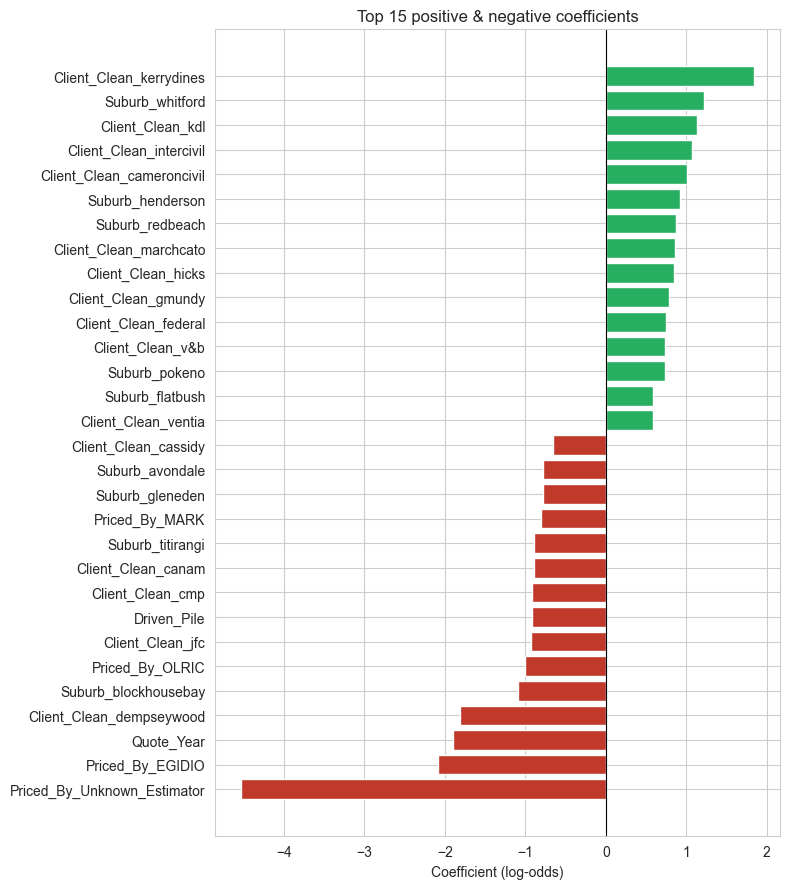

,feature,coefficient,odds_ratio
54,Client_Clean_kerrydines,1.843938,6.321385
121,Suburb_whitford,1.220028,3.387281
53,Client_Clean_kdl,1.130590,3.097484
50,Client_Clean_intercivil,1.073544,2.925731
26,Client_Clean_cameroncivil,1.006700,2.736554
87,Suburb_henderson,0.920299,2.510042
109,Suburb_redbeach,0.866539,2.378665
57,Client_Clean_marchcato,0.854161,2.349402
48,Client_Clean_hicks,0.849301,2.338012
42,Client_Clean_gmundy,0.787279,2.197409


In [41]:
feature_names = best_log_reg.named_steps['preprocessor'].get_feature_names_out()
clean_names = [f.replace('num__','').replace('bin__','').replace('cat__','') for f in feature_names]
coefs = best_log_reg.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': clean_names, 'coefficient': coefs})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df = coef_df.sort_values('coefficient', ascending=False)

top_n = 15
plot_df = pd.concat([coef_df.head(top_n), coef_df.tail(top_n)]).drop_duplicates()
fig, ax = plt.subplots(figsize=(8, 9))
colors = ['#27ae60' if c > 0 else '#c0392b' for c in plot_df['coefficient']]
ax.barh(plot_df['feature'], plot_df['coefficient'], color=colors)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title(f'Top {top_n} positive & negative coefficients')
ax.axvline(0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

coef_df.head(15)


**Reading odds ratios:** an odds ratio of 2.0 means winning odds roughly double when that feature is present (or per +1 SD, for scaled numeric features) holding everything else fixed; 0.5 means odds roughly halve. Interpret the client/suburb-specific ones cautiously — see the bootstrap check below, since several are estimated from a fairly small number of quotations.

In [42]:
# Bootstrap confidence intervals -- resample training ROWS after fixing the encoding,
# so every bootstrap iteration produces the same feature columns and stays comparable.
N_BOOT = 300
X_train_enc = best_log_reg.named_steps['preprocessor'].transform(X_train)
best_C = grid_search.best_params_['model__C']
y_train_arr = y_train.values
n = X_train_enc.shape[0]

rng = np.random.RandomState(RANDOM_STATE)
boot_coefs = np.zeros((N_BOOT, X_train_enc.shape[1]))
for i in range(N_BOOT):
    idx = rng.randint(0, n, n)
    Xb, yb = X_train_enc[idx], y_train_arr[idx]
    m = LogisticRegression(C=best_C, class_weight='balanced', max_iter=2000)
    m.fit(Xb, yb)
    boot_coefs[i] = m.coef_[0]

ci_low = np.percentile(boot_coefs, 2.5, axis=0)
ci_high = np.percentile(boot_coefs, 97.5, axis=0)
sig = np.sign(ci_low) == np.sign(ci_high)

boot_df = pd.DataFrame({'feature': clean_names, 'coef_mean': boot_coefs.mean(axis=0),
                         'ci_2.5%': ci_low, 'ci_97.5%': ci_high, 'significant_95pct_CI': sig})
print(f'{sig.sum()} / {len(sig)} features have a 95% bootstrap CI that excludes zero.')
boot_df[boot_df['significant_95pct_CI']].sort_values('coef_mean', ascending=False)


30 / 133 features have a 95% bootstrap CI that excludes zero.


,feature,coef_mean,ci_2.5%,ci_97.5%,significant_95pct_CI
54,Client_Clean_kerrydines,1.633875,0.677655,2.375887,True
53,Client_Clean_kdl,1.173510,0.403881,1.882522,True
26,Client_Clean_cameroncivil,1.148734,0.266344,1.904922,True
121,Suburb_whitford,1.096642,0.194166,1.936502,True
132,Priced_By_infrequent_sklearn,0.948775,0.181890,1.774736,True
42,Client_Clean_gmundy,0.916901,0.063287,1.773911,True
87,Suburb_henderson,0.877715,0.171125,1.587574,True
57,Client_Clean_marchcato,0.873744,0.305733,1.455123,True
48,Client_Clean_hicks,0.869636,0.397811,1.322656,True
125,Priced_By_GARY,0.634702,0.119336,1.150550,True


Treat features **not** flagged as significant above with real skepticism, even if they showed up with a large coefficient in the plot before this — that combination is the signature of a category with too few observations to trust.

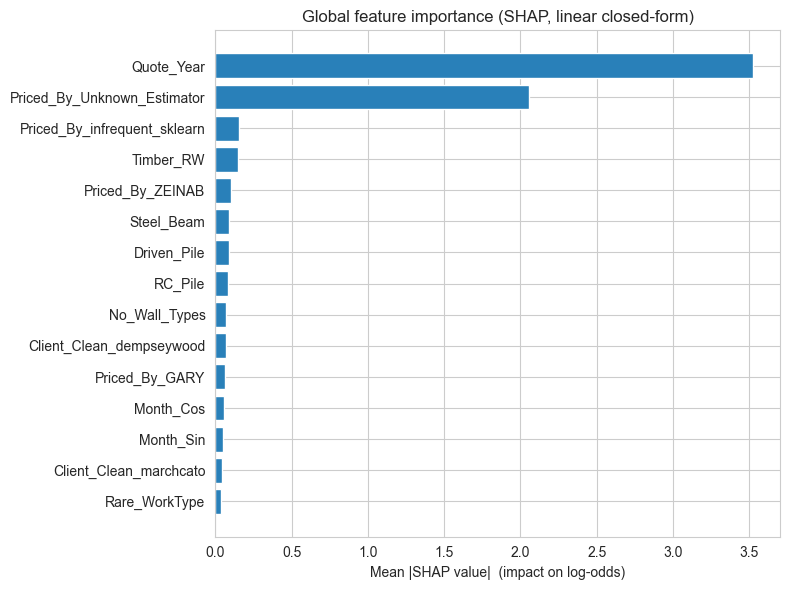

In [44]:
# Manual closed-form linear SHAP (interventional): phi_i = coef_i * (x_i - mean(x_i)).
# This has no external dependency and is exactly what shap.LinearExplainer computes,
# so it also works as a correctness check on the shap-library plot in the next cell.
X_test_enc = best_log_reg.named_steps['preprocessor'].transform(X_test)
lr_model = best_log_reg.named_steps['model']

mean_train_enc = X_train_enc.mean(axis=0)
base_value = lr_model.intercept_[0] + np.dot(lr_model.coef_[0], mean_train_enc)
shap_manual = (X_test_enc - mean_train_enc) * lr_model.coef_[0]

mean_abs_shap = pd.DataFrame({'feature': clean_names, 'mean_abs_shap': np.abs(shap_manual).mean(axis=0)})
mean_abs_shap = mean_abs_shap.sort_values('mean_abs_shap', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(mean_abs_shap['feature'], mean_abs_shap['mean_abs_shap'], color='#2980b9')
ax.set_xlabel('Mean |SHAP value|  (impact on log-odds)')
ax.set_title('Global feature importance (SHAP, linear closed-form)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**This is the second headline finding, and it reinforces the first:** `Quote_Year` and `Priced_By_Unknown_Estimator` dominate feature importance — well above any individual client, suburb, or work-type effect. Digging into why: `Priced_By` was essentially unpopulated before 2020 and essentially always populated from 2020 onward (a near-perfect step function, not a random gap), so `Priced_By_Unknown_Estimator` is largely standing in for "this is an old record" — overlapping heavily with `Quote_Year` rather than adding independent business signal. In other words: **most of what this model has learned is "win rate has fallen over time,"** not granular client/project drivers. That's a legitimate pattern, but worth deciding deliberately:

- Keep both, accepting the redundancy (harmless for prediction, slightly muddies interpretation)
- Drop `Priced_By` and rely on `Quote_Year`/`Month_Sin`/`Month_Cos` for the temporal trend, keeping the coefficient table focused on business drivers
- Engineer a cleaner "CRM era" flag if you know what actually changed operationally around 2020

Your call — happy to implement whichever once you've had a look.

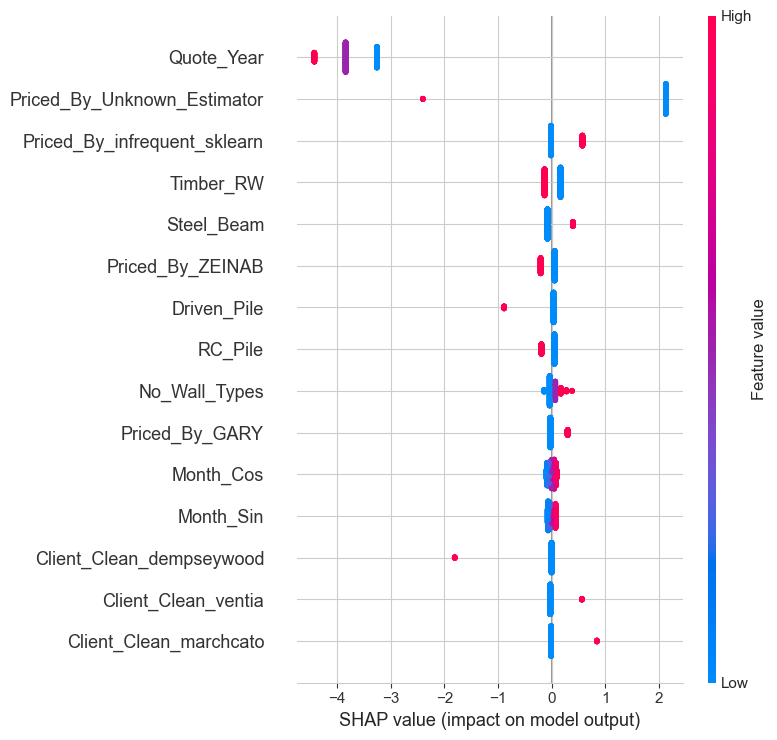

In [45]:
# Standard shap-library workflow (same numbers as the manual computation above; useful because
# we'll reuse this exact pattern for the tree-based models coming next).
import shap

explainer = shap.LinearExplainer(lr_model, X_train_enc, feature_names=clean_names)
shap_values = explainer(X_test_enc)

shap.summary_plot(shap_values, X_test_enc, feature_names=clean_names, max_display=15, show=True)


### Explaining a single prediction (waterfall)

The summary plot above is *global* — averaged over every test-set prediction. A waterfall plot is *local* — it explains one specific quotation, which is what you'd actually show someone asking "why does the model think we'll win this one?" Picking the quotation the model is most confident about among actual wins in the test set, as a clear example (swap `example_idx` for any row you want to inspect instead).

Example: test row 270, actual = Won, predicted probability = 0.551


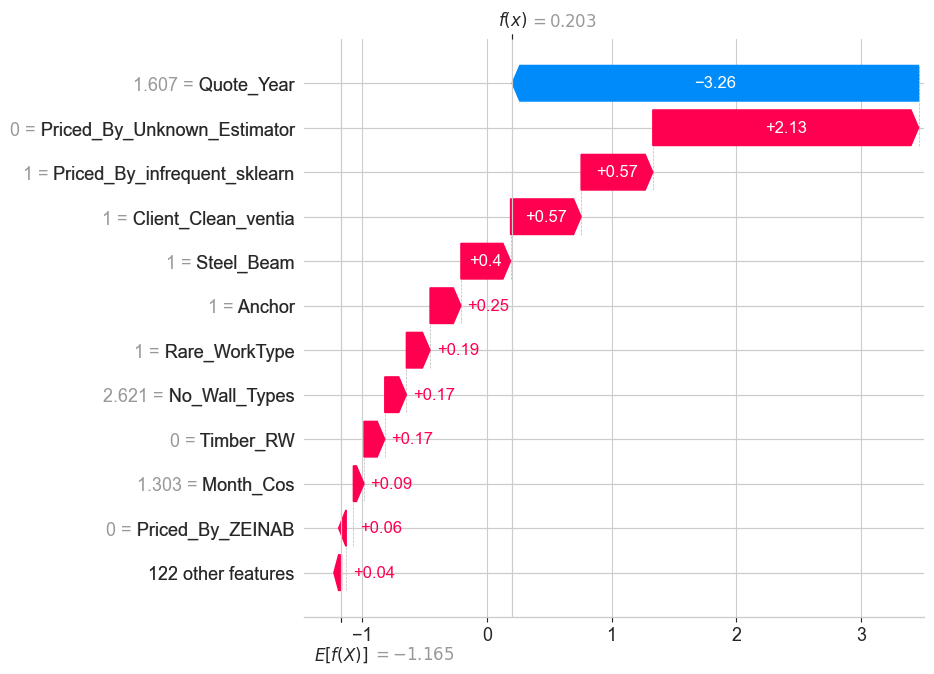

In [46]:
# Among actual wins in the test set, find the one the model was most confident about.
test_idx_won = np.where(y_test.values == 1)[0]
example_idx = test_idx_won[np.argmax(y_proba_best[test_idx_won])]
print(f'Example: test row {example_idx}, actual = Won, predicted probability = {y_proba_best[example_idx]:.3f}')

shap.plots.waterfall(shap_values[example_idx], max_display=12)


Guaranteed-to-render fallback using the manual SHAP computation from above, in case of any `shap`-version rendering quirk in your environment — same numbers, plain matplotlib:

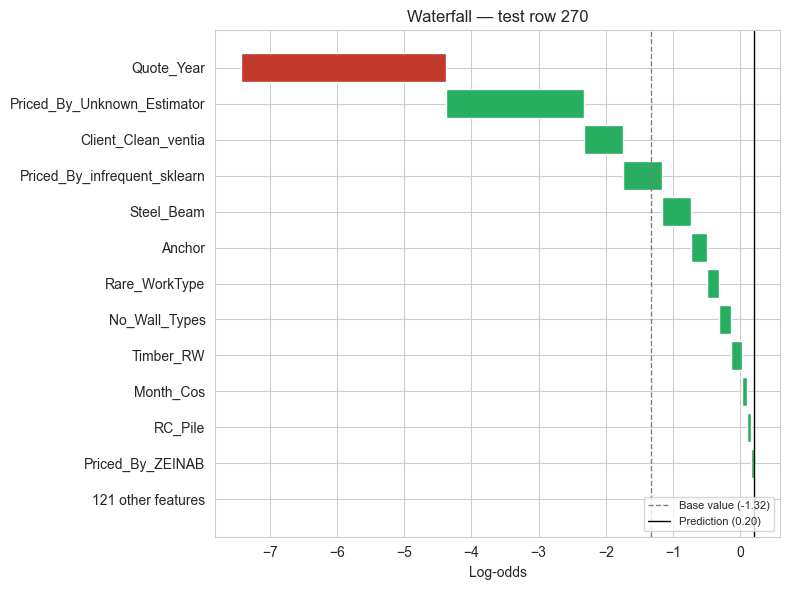

In [47]:
def manual_waterfall(idx, top_n=12):
    contribs = pd.Series(shap_manual[idx], index=clean_names)
    top = contribs.reindex(contribs.abs().sort_values(ascending=False).index).head(top_n)
    other = contribs.drop(top.index).sum()
    parts = pd.concat([top, pd.Series({f'{len(contribs)-top_n} other features': other})])

    running = base_value
    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (name, val) in enumerate(parts.items()):
        color = '#27ae60' if val > 0 else '#c0392b'
        ax.barh(i, val, left=running if val > 0 else running + val, color=color)
        running += val
    ax.set_yticks(range(len(parts)))
    ax.set_yticklabels(parts.index)
    ax.axvline(base_value, color='gray', linestyle='--', linewidth=1, label=f'Base value ({base_value:.2f})')
    ax.axvline(base_value + contribs.sum(), color='black', linestyle='-', linewidth=1, label=f'Prediction ({base_value + contribs.sum():.2f})')
    ax.set_xlabel('Log-odds')
    ax.set_title(f'Waterfall — test row {idx}')
    ax.legend(loc='lower right', fontsize=8)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

manual_waterfall(example_idx)


## Model Calibration

**Why this matters here specifically:** `predict_proba` on a model tuned with `class_weight='balanced'` (or selected via a ranking metric like PR-AUC, as in Part 6) is not guaranteed to output *calibrated* probabilities — a predicted 0.35 doesn't necessarily mean "35% chance of winning" in the literal, frequency sense. That distinction matters a lot for a business use case like `expected_value = P(win) × Value` — if the probabilities are systematically off, so is every downstream expected-value calculation, even if the model *ranks* quotations correctly.

**Method:** fit the tuned pipeline on the first 80% of the training period, hold back the last 20% purely to fit a calibration mapping (`CalibratedClassifierCV`, Platt/sigmoid scaling — a good fit for logistic regression specifically, and more reliable than isotonic on a calibration set this size), then evaluate on the untouched final test set. This needs its own held-out slice — reusing the training data the model already saw would make the calibration curve look better than it will on genuinely new data, the same leakage concern as everywhere else in this notebook. Using `FrozenEstimator` (scikit-learn ≥ 1.6) rather than passing `cv=TimeSeriesSplit(...)` directly to `CalibratedClassifierCV` is a deliberate choice too — the latter refits several base models on different amounts of history and averages them into an ensemble, which changes the model being explained above, not just its probability scale. If you're on an older scikit-learn without `FrozenEstimator`, `CalibratedClassifierCV(base_estimator=calib_base, cv='prefit')` is the equivalent.

In [48]:
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

# split the training period itself into a fit slice and a calibration slice (chronological, no shuffling)
calib_split = int(split_idx * 0.8)
X_cfit, y_cfit = X.iloc[:calib_split], y.iloc[:calib_split]
X_calib, y_calib = X.iloc[calib_split:split_idx], y.iloc[calib_split:split_idx]
print(f'Fit: {len(X_cfit)} | Calibrate: {len(X_calib)} | Test (unchanged): {len(X_test)}')

calib_base = clone(best_log_reg)          # same tuned hyperparameters, unfitted
calib_base.fit(X_cfit, y_cfit)
proba_uncalibrated = calib_base.predict_proba(X_test)[:, 1]

calibrated_log_reg = CalibratedClassifierCV(FrozenEstimator(calib_base), method='sigmoid')
calibrated_log_reg.fit(X_calib, y_calib)
proba_calibrated = calibrated_log_reg.predict_proba(X_test)[:, 1]

print(f'Brier score, uncalibrated: {brier_score_loss(y_test, proba_uncalibrated):.4f}')
print(f'Brier score, calibrated  : {brier_score_loss(y_test, proba_calibrated):.4f}   (lower is better)')
print(f'ROC-AUC, uncalibrated: {roc_auc_score(y_test, proba_uncalibrated):.3f}')
print(f'ROC-AUC, calibrated  : {roc_auc_score(y_test, proba_calibrated):.3f}   (should be ~identical -- calibration rescales, it does not re-rank)')


Fit: 2841 | Calibrate: 711 | Test (unchanged): 889
Brier score, uncalibrated: 0.1557
Brier score, calibrated  : 0.1411   (lower is better)
ROC-AUC, uncalibrated: 0.583
ROC-AUC, calibrated  : 0.583   (should be ~identical -- calibration rescales, it does not re-rank)


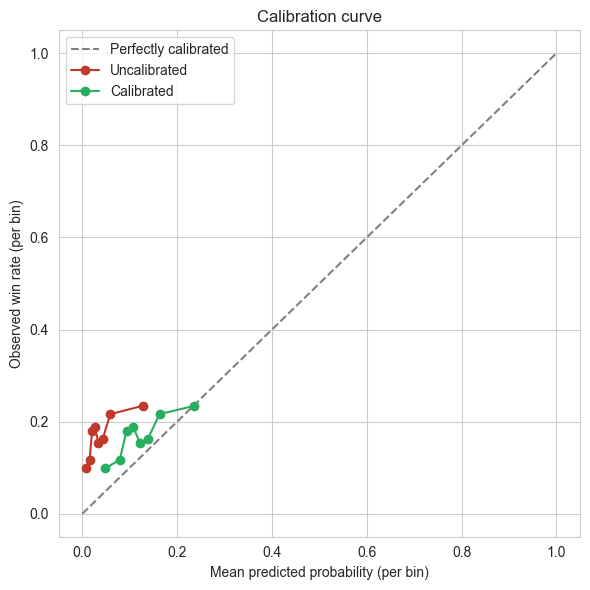

In [49]:
frac_pos_u, mean_pred_u = calibration_curve(y_test, proba_uncalibrated, n_bins=8, strategy='quantile')
frac_pos_c, mean_pred_c = calibration_curve(y_test, proba_calibrated, n_bins=8, strategy='quantile')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
ax.plot(mean_pred_u, frac_pos_u, marker='o', color='#c0392b', label='Uncalibrated')
ax.plot(mean_pred_c, frac_pos_c, marker='o', color='#27ae60', label='Calibrated')
ax.set_xlabel('Mean predicted probability (per bin)')
ax.set_ylabel('Observed win rate (per bin)')
ax.set_title('Calibration curve')
ax.legend()
plt.tight_layout()
plt.show()


Points above the diagonal mean the model is under-confident in that range (actual win rate higher than predicted); below means over-confident. Whichever direction it comes out for your run, the calibrated curve should track the diagonal noticeably more closely than the raw one — same information the model already had, just rescaled to mean what it says.

**One more decoupling worth doing deliberately:** once probabilities are trustworthy, the *classification* threshold (currently the sklearn default of 0.5) doesn't have to be either. A threshold chosen for business reasons — "flag any quote above 40% for a follow-up call," "only auto-approve a discount above 60%" — is a separate decision from calibration, and arguably the more important one for how this model actually gets used day to day. Not implemented here since it depends on costs/benefits only you know, but happy to build it out (e.g. a threshold that maximizes expected value, or hits a target recall) once we're past model selection.

## Summary & Open Questions

**What this notebook found, beyond the model itself:**
- `Successful` is target leakage (dropped); `number_of_successful` looks mislabeled at the source (dropped, worth a look upstream)
- Several columns hide real missingness behind sentinel text (`Suburb` ~38%, `Priced_By` ~38%, `Date_Sent` ~48%, `Due_Date` ~65%) — handled, but `Due_Date`/`Date_Sent`-derived features should be trusted less given how sparse they are
- **Win rate has roughly halved since 2021–2022**, with a wave-shaped seasonal pattern within each year too — the dominant pattern in the data, and worth a conversation with the business about what changed
- A time-based split is materially harder (and more honest) than a random split for this data
- `Priced_By`'s missingness is essentially a proxy for time period, not a real "estimator identity" signal in the recent data — while co-estimation (`Multi_Estimator`) looks like a genuine, if partially value-correlated, signal of project significance
- Tuning showed `class_weight` mainly trades off against a fixed 0.5 threshold rather than changing ranking quality — worth choosing a business-driven threshold deliberately rather than defaulting to 0.5
- Raw `predict_proba` output needed recalibrating before it's safe to use in expected-value calculations; `calibrated_log_reg` is the version to reach for if you want probabilities, `best_log_reg` for the coefficient/SHAP explanations above

**Questions for you before we lock in the pipeline for the remaining 6 models:**
1. Does the `Successful` = "won contract value" interpretation match the source system?
2. Any idea what changed operationally around 2022–2023 that could explain the win-rate drop?
3. Keep, drop, or redesign `Priced_By` given its overlap with `Quote_Year`?
4. Is the ~5% of rows with `Value` ≤ 0 (mostly Design & Build / Budget quotes) meant to be treated differently?
5. Happy with grouping thresholds (`MIN_CATEGORY_COUNT=15`, rare wall-types <1%), or want them looser/tighter?
6. Any preference for how the final win/loss threshold should be chosen (target recall, target precision, expected-value based) once we're comparing across all 7 models?

**Once we agree on these, the cleaning in Part 2 carries over unchanged to Decision Tree, Random Forest, XGBoost, LightGBM, CatBoost and the Neural Network** — only the preprocessing specifics (encoding, scaling) and the model itself will differ per algorithm.

In [ ]:
import joblib
joblib.dump(best_log_reg, 'logistic_regression_pipeline.joblib')
joblib.dump(calibrated_log_reg, 'logistic_regression_calibrated.joblib')
print('Saved logistic_regression_pipeline.joblib (for coefficients/SHAP) and logistic_regression_calibrated.joblib (for probability/expected-value use)')
